In [106]:
import matplotlib.pyplot as plt
import numpy as np

from astropy.visualization import time_support

from sunpy import timeseries as ts
from sunpy.net import Fido
from sunpy.net import attrs as a

from stixpy.net.client import STIXClient
from stixpy.timeseries import quicklook 

import datetime as dt
from sunpy.time import parse_time
from sunpy.time import TimeRange
from astropy.time import Time

import pandas as pd

In [13]:
lf_query = Fido.search(a.Time('2024-10-03T12:04:29.984', '2024-10-03T13:15:41.992'), 
                       a.Instrument.stix, 
                       a.stix.DataProduct.ql_lightcurve)

lf_file = Fido.fetch(lf_query)

lf_lc = ts.TimeSeries(lf_file)
lf_df = lf_lc.to_dataframe()

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

In [3]:
goes_lf_result = Fido.search(a.Time('2024-10-03T12:04:29.984', '2024-10-03T13:15:41.992'),
                     a.Instrument("XRS"),
                     a.goes.SatelliteNumber(16))

goes_lf_files = Fido.fetch(goes_lf_result)

goes_lf = ts.TimeSeries(goes_lf_files, concatenate=True)
goes_lf_trunc = goes_lf.truncate('2024-10-03T12:04:29.984', '2024-10-03T13:15:41.992')
goes_lf_df = goes_lf_trunc.to_dataframe()
goes_lf_df

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

,xrsa,xrsb,xrsa_quality,xrsb_quality,xrsa_primary_chan,xrsb_primary_chan
2024-10-03 12:04:30.269102,6.244113e-07,0.000011,0,0,1.0,1.0
2024-10-03 12:04:31.269106,6.200805e-07,0.000011,0,0,1.0,1.0
2024-10-03 12:04:32.269105,6.136241e-07,0.000011,0,0,1.0,1.0
2024-10-03 12:04:33.269112,6.179390e-07,0.000011,0,0,1.0,1.0
2024-10-03 12:04:34.269112,6.168443e-07,0.000011,0,0,1.0,1.0
...,...,...,...,...,...,...
2024-10-03 13:15:37.281012,1.008097e-06,0.000015,0,0,1.0,1.0
2024-10-03 13:15:38.281014,9.875849e-07,0.000015,0,0,1.0,1.0
2024-10-03 13:15:39.281021,1.022120e-06,0.000015,0,0,1.0,1.0
2024-10-03 13:15:40.281020,1.004861e-06,0.000015,0,0,1.0,1.0


In [17]:
working_df = lf_df.copy()

earth_tdel = lf_lc.meta.metas[0]["EAR_TDEL"]
shifted_times = lf_lc.time+dt.timedelta(seconds=earth_tdel)
working_df.index = shifted_times

tstart = parse_time('2024-10-03T12:04:29.984')
tstart_s = tstart+dt.timedelta(seconds=earth_tdel)

tend = parse_time('2024-10-03T13:15:41.992')
tend_s = tend+dt.timedelta(seconds=earth_tdel)

tr=TimeRange(tstart_s, tend_s)

In [20]:
lf_lc_f = ts.TimeSeries(working_df, lf_lc.meta, lf_lc.units)
lf_lc_trunc = lf_lc_f.truncate(tr)

In [102]:
lf_lc_trunc.time[start_end[0][0]]

<Time object: scale='utc' format='iso' value=2024-10-03 12:14:49.971>

In [107]:
for pair in start_end:
    print(Time(lf_lc_trunc.time[pair[0]]), Time(lf_lc_trunc.time[pair[1]]))

2024-10-03 12:14:49.971 2024-10-03 12:31:49.971
2024-10-03 12:33:53.971 2024-10-03 12:35:49.971


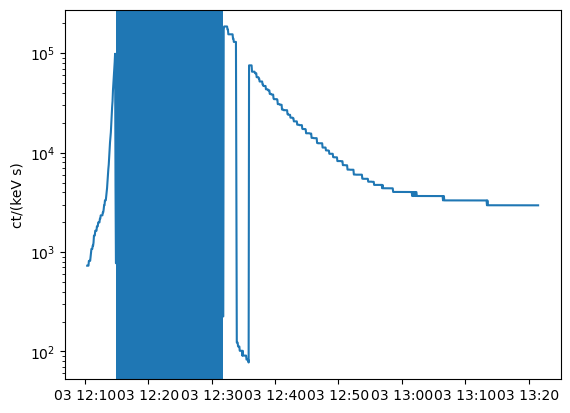

In [112]:

fig, ax = plt.subplots()
ax.set_yscale('log')
ax.set_ylabel('ct/(keV s)')

ax.plot(lf_lc_trunc.time.datetime, lf_lc_trunc.quantity('4-10 keV'))
plt.axvspan(lf_lc_trunc.time[start_end[0][0]].datetime, lf_lc_trunc.time[start_end[0][1]].datetime)

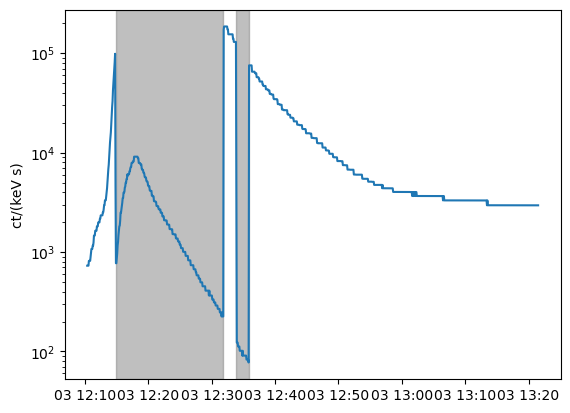

In [113]:

fig, ax = plt.subplots()
ax.set_yscale('log')
ax.set_ylabel('ct/(keV s)')

ax.plot(lf_lc_trunc.time.datetime, lf_lc_trunc.quantity('4-10 keV'))

for pair in start_end:
    plt.axvspan(lf_lc_trunc.time[pair[0]].datetime, lf_lc_trunc.time[pair[1]].datetime, color='grey', alpha=0.5)

ConversionError: Failed to convert value(s) to axis units: [<Time object: scale='utc' format='iso' value=2024-10-03 12:14:49.971>, <Time object: scale='utc' format='iso' value=2024-10-03 12:31:49.971>]

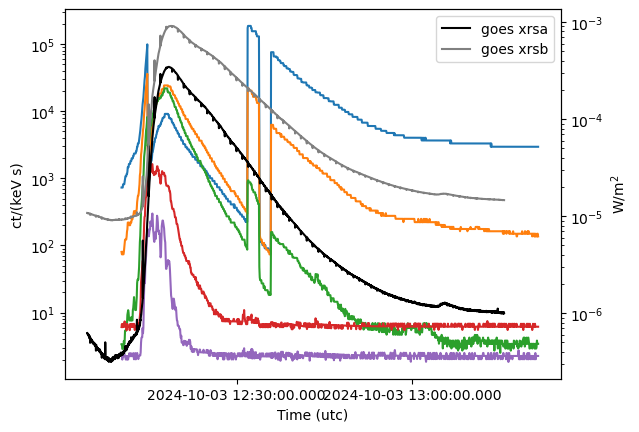

In [101]:
time_support()
fig, ax = plt.subplots()
ax.set_yscale('log')
ax.set_ylabel('ct/(keV s)')

ax.plot(lf_lc_trunc.time, lf_lc_trunc.quantity('4-10 keV'))
ax.plot(lf_lc_trunc.time, lf_lc_trunc.quantity('10-15 keV'))
ax.plot(lf_lc_trunc.time, lf_lc_trunc.quantity('15-25 keV'))
ax.plot(lf_lc_trunc.time, lf_lc_trunc.quantity('25-50 keV'))
ax.plot(lf_lc_trunc.time, lf_lc_trunc.quantity('50-84 keV'))

goes_ax = ax.twinx()
goes_ax.set_yscale('log')
goes_ax.set_ylabel('W/m$^{2}$')

goes_ax.plot(goes_lf_trunc.time, goes_lf_trunc.quantity('xrsa'), label = 'goes xrsa', color = 'black')
goes_ax.plot(goes_lf_trunc.time, goes_lf_trunc.quantity('xrsb'), label = 'goes xrsb', color='gray')
goes_ax.legend()

#plt.axvline(dt.datetime.fromisoformat('2024-10-03 12:12:37'), 0, 1, color = 'grey', linestyle = 'dashed')

for pair in start_end:
    plt.axvspan(lf_lc_trunc.time[pair[0]], lf_lc_trunc.time[pair[1]])

In [29]:
working_df.index

Index([2024-10-03 00:05:50.171, 2024-10-03 00:05:54.171,
       2024-10-03 00:05:58.171, 2024-10-03 00:06:02.171,
       2024-10-03 00:06:06.171, 2024-10-03 00:06:10.171,
       2024-10-03 00:06:14.171, 2024-10-03 00:06:18.171,
       2024-10-03 00:06:22.171, 2024-10-03 00:06:26.171,
       ...
       2024-10-04 00:05:09.971, 2024-10-04 00:05:13.971,
       2024-10-04 00:05:17.971, 2024-10-04 00:05:21.971,
       2024-10-04 00:05:25.971, 2024-10-04 00:05:29.971,
       2024-10-04 00:05:33.971, 2024-10-04 00:05:37.971,
       2024-10-04 00:05:41.971, 2024-10-04 00:05:45.971],
      dtype='object', length=21600)

In [41]:


att_condition = working_df['rcr']!=0
att_in_start = working_df[att_condition & working_df['rcr'].shift(1)==0].index

In [97]:
lf_df_trunc = lf_lc_trunc.to_dataframe()

In [98]:
att_in_index = np.where(lf_df_trunc['rcr']!=0)
starts=[]
for n in range((np.shape(att_in_index))[1]):
    # if n==0:
    #     starts.append(att_in_index[0][n])
    if att_in_index[0][n]!=1+att_in_index[0][n-1]:
        starts.append(att_in_index[0][n])

ends=[]
for n in range((np.shape(att_in_index))[1]):
    if n==(np.shape(att_in_index))[1]-1:
        ends.append(att_in_index[0][n])
        break
    elif att_in_index[0][n]!=att_in_index[0][n+1]-1:
        ends.append(att_in_index[0][n])

start_end = list(zip(starts, ends))


In [99]:
lf_lc_trunc.time[0]

<Time object: scale='utc' format='iso' value=2024-10-03 12:10:21.971>

In [100]:
lf_lc_trunc.time[start_end[0][0]]

<Time object: scale='utc' format='iso' value=2024-10-03 12:14:49.971>

In [85]:
starts

[np.int64(10935), np.int64(11221)]

In [83]:
ends

[np.int64(11190), np.int64(11250)]

In [43]:
att_in

,control_index,timedel,triggers,triggers_comp_err,rcr,4-10 keV,10-15 keV,15-25 keV,25-50 keV,50-84 keV,4-10 keV_comp_err,10-15 keV_comp_err,15-25 keV_comp_err,25-50 keV_comp_err,50-84 keV_comp_err
time,,,,,,,,,,,,,,,
2024-10-03 12:08:59.902,20,400.0,475135,9459.306641,1,4692.712838,2815.600206,3040.880119,855.948182,157.337350,2364.826660,1182.413452,2364.826660,2364.826660,591.206787
2024-10-03 12:09:03.902,20,400.0,311295,9459.306641,1,771.173217,1578.674466,3157.428676,914.562614,168.112264,591.206787,591.206787,2364.826660,2364.826660,591.206787
2024-10-03 12:09:07.902,20,400.0,311295,9459.306641,1,771.173217,1687.552233,3157.428676,914.562614,152.100828,591.206787,591.206787,2364.826660,2364.826660,591.206787
2024-10-03 12:09:11.902,20,400.0,344063,9459.306641,1,867.680976,1863.272980,3397.803916,920.691802,137.001431,591.206787,1182.413452,2364.826660,2364.826660,591.206787
2024-10-03 12:09:15.902,20,400.0,376831,9459.306641,1,965.490659,2096.537620,3751.768375,1015.180898,154.153216,591.206787,1182.413452,4729.653320,2364.826660,591.206787
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-03 12:29:43.902,21,400.0,7935,147.802231,1,82.750524,80.071460,18.402915,6.720194,2.231326,36.952671,36.952671,18.479719,18.479719,9.246621
2024-10-03 12:29:47.902,21,400.0,7935,147.802231,1,82.750524,73.661737,18.402915,6.720194,2.466977,36.952671,36.952671,18.479719,18.479719,9.246621
2024-10-03 12:29:51.902,21,400.0,7935,147.802231,1,82.750524,73.661737,20.005346,6.720194,2.231326,36.952671,36.952671,18.479719,18.479719,9.246621


In [42]:
att_in_start

Index([2024-10-03 00:05:50.171, 2024-10-03 00:05:54.171,
       2024-10-03 00:05:58.171, 2024-10-03 00:06:02.171,
       2024-10-03 00:06:06.171, 2024-10-03 00:06:10.171,
       2024-10-03 00:06:14.171, 2024-10-03 00:06:18.171,
       2024-10-03 00:06:22.171, 2024-10-03 00:06:26.171,
       ...
       2024-10-04 00:05:09.971, 2024-10-04 00:05:13.971,
       2024-10-04 00:05:17.971, 2024-10-04 00:05:21.971,
       2024-10-04 00:05:25.971, 2024-10-04 00:05:29.971,
       2024-10-04 00:05:33.971, 2024-10-04 00:05:37.971,
       2024-10-04 00:05:41.971, 2024-10-04 00:05:45.971],
      dtype='object', length=21316)

In [34]:
starts = working_df[working_df['rcr']!=0 & ]
starts

,control_index,timedel,triggers,triggers_comp_err,rcr,4-10 keV,10-15 keV,15-25 keV,25-50 keV,50-84 keV,4-10 keV_comp_err,10-15 keV_comp_err,15-25 keV_comp_err,25-50 keV_comp_err,50-84 keV_comp_err
2024-10-03 12:14:49.971,20,400.0,475135,9459.306641,1,4692.712838,2815.600206,3040.880119,855.948182,157.337350,2364.826660,1182.413452,2364.826660,2364.826660,591.206787
2024-10-03 12:14:53.971,20,400.0,311295,9459.306641,1,771.173217,1578.674466,3157.428676,914.562614,168.112264,591.206787,591.206787,2364.826660,2364.826660,591.206787
2024-10-03 12:14:57.971,20,400.0,311295,9459.306641,1,771.173217,1687.552233,3157.428676,914.562614,152.100828,591.206787,591.206787,2364.826660,2364.826660,591.206787
2024-10-03 12:15:01.971,20,400.0,344063,9459.306641,1,867.680976,1863.272980,3397.803916,920.691802,137.001431,591.206787,1182.413452,2364.826660,2364.826660,591.206787
2024-10-03 12:15:05.971,20,400.0,376831,9459.306641,1,965.490659,2096.537620,3751.768375,1015.180898,154.153216,591.206787,1182.413452,4729.653320,2364.826660,591.206787
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-03 12:35:33.971,21,400.0,7935,147.802231,1,82.750524,80.071460,18.402915,6.720194,2.231326,36.952671,36.952671,18.479719,18.479719,9.246621
2024-10-03 12:35:37.971,21,400.0,7935,147.802231,1,82.750524,73.661737,18.402915,6.720194,2.466977,36.952671,36.952671,18.479719,18.479719,9.246621
2024-10-03 12:35:41.971,21,400.0,7935,147.802231,1,82.750524,73.661737,20.005346,6.720194,2.231326,36.952671,36.952671,18.479719,18.479719,9.246621
2024-10-03 12:35:45.971,21,400.0,7423,147.802231,1,82.742413,73.654517,18.401112,6.078626,2.231107,36.952671,36.952671,18.479719,18.479719,9.246621


In [46]:
att_in = lf_df[lf_df['rcr']!=0]

att_condition = working_df['rcr']!=0
att_in_start = att_in[working_df['rcr'].shift(1)==0].index

C:\Users\derva\AppData\Local\Temp\ipykernel_16236\699278775.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  att_in_start = att_in[working_df['rcr'].shift(1)==0].index


IndexingError: Unalignable boolean Series provided as indexer (index of the boolean Series and of the indexed object do not match).

In [45]:
att_in_start

Index([2024-10-03 00:05:50.171, 2024-10-03 00:05:54.171,
       2024-10-03 00:05:58.171, 2024-10-03 00:06:02.171,
       2024-10-03 00:06:06.171, 2024-10-03 00:06:10.171,
       2024-10-03 00:06:14.171, 2024-10-03 00:06:18.171,
       2024-10-03 00:06:22.171, 2024-10-03 00:06:26.171,
       ...
       2024-10-04 00:05:09.971, 2024-10-04 00:05:13.971,
       2024-10-04 00:05:17.971, 2024-10-04 00:05:21.971,
       2024-10-04 00:05:25.971, 2024-10-04 00:05:29.971,
       2024-10-04 00:05:33.971, 2024-10-04 00:05:37.971,
       2024-10-04 00:05:41.971, 2024-10-04 00:05:45.971],
      dtype='object', length=21316)

In [47]:
lf_lc_trunc.time

<Time object: scale='utc' format='iso' value=['2024-10-03 12:10:21.971' '2024-10-03 12:10:25.971'
 '2024-10-03 12:10:29.971' ... '2024-10-03 13:21:21.971'
 '2024-10-03 13:21:25.971' '2024-10-03 13:21:29.971']>